Removed no burn in


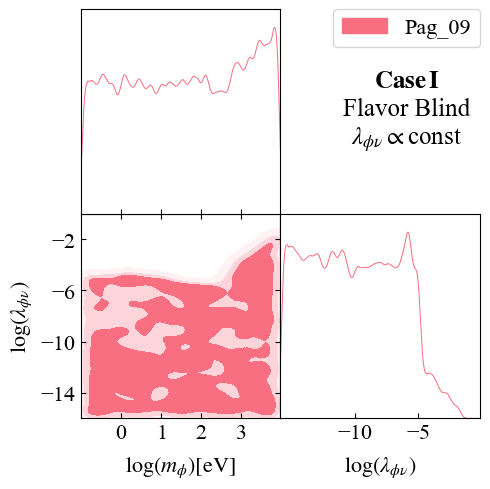

In [ ]:
import numpy as np
import corner
from getdist import MCSamples, plots
import corner
import matplotlib.pyplot as plt

model_names = ['Pag_09', 'Var_23']
names = ['log_m_phi', 'log_lambda']
labels = [r'\mathrm{log}(m_\phi)\mathrm{[eV]}', r'\mathrm{log}(\lambda_{\phi\nu})']

data_1d = np.load('./Bin/smellycat260817/data/InverseS/8p_5e5_p32_IS_1e-2Tnu.npy')
samples_A = MCSamples(samples=data_1d[:,-2:], names=names, labels=labels, label='1d')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

limits = {
r'log_m_phi': [-1, 4], 
r'log_lambda': [-16, 0]          
}

g = plots.get_subplot_plotter(width_inch=5)  

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

samples_A.updateSettings({'contours': [0.68, 0.95, 0.997]})
g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0


g.triangle_plot(
    samples_A,
    filled=True, 
    contour_colors= ['#f76f81'], # Optional: override default colors
    legend_labels=[model_names[0]], # Optional: legend labels
    param_limits=limits
)


my_text = r'$\mathbf{Case\, I}$'+ '\nFlavor Blind'+ "\n"+r'$\lambda_{\phi\nu} \propto $const ' 

g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right', 
           va='top',
           multialignment='center')
g.export(r".\Plots\P_corner_I.pdf")

g.fig

Removed no burn in


log_m_phi: Peak=3.64, 2-sigma HPD=[-4.43, +0.51]
log_lambda: Peak=-5.48, 2-sigma HPD=[-10.43, +4.39]


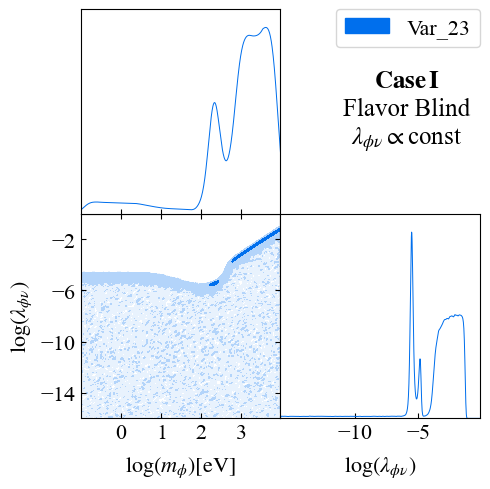

In [ ]:
import numpy as np
import corner
from getdist import MCSamples, plots
import corner
import matplotlib.pyplot as plt


effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]

data_list = []

for file_id in effective_data_file:
    path = f'./Bin/smellycat260817/data/InverseS/2d_m{file_id}_5e5_p32_IS_1e-2Tnu.npy'
    arr = np.load(path) # shape (2000, 2)
    data_list.append(arr)

data_all = np.concatenate(data_list, axis=0)

samples_B = MCSamples(samples=data_all, names=names, labels=labels, label='2d')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

g = plots.get_subplot_plotter(width_inch=5)

g.settings.axes_labelsize = 18
g.settings.axes_fontsize = 18
g.settings.legend_fontsize = 18

# samples_B.updateSettings({'contours': [0.68, 0.95, 0.997]})
g.settings.num_plot_contours = 3
g.settings.alpha_filled_add = 0.9
g.settings.solid_contour_palefactor = 0.7
g.settings.alpha_factor_contour_lines = 0


g.triangle_plot(
    [samples_B],
    filled=True, 
    contour_colors=["#006FED"], # Optional: override default colors
    legend_labels=[model_names[1]], # Optional: legend labels
    param_limits=limits,

)


# calculate 1D HPD intervals and plot them on the diagonal subplots
for i, param_name in enumerate(names):
    
    density = samples_B.get1DDensity(param_name)
    x = density.x
    P = density.P
    
    sort_idx = np.argsort(P)[::-1]
    sorted_P = P[sort_idx]
    
    cum_prob = np.cumsum(sorted_P)
    cum_prob /= cum_prob[-1] # Normalize the probabilities
    
    idx_1sigma = sort_idx[cum_prob <= 0.6827]
    idx_2sigma = sort_idx[cum_prob <= 0.9545]
    
    peak_idx = np.argmax(P)
    peak_value = x[peak_idx]
    ax = g.subplots[i, i]
    
    # ax.axvline(peak_value, color='#df65b0', ls='-', lw=1.5, alpha=0.8)

    if_s_1= False
    if_s_2= True

    if if_s_1:
        if len(idx_1sigma) > 0:
            lower_1sigma = np.min(x[idx_1sigma])
            upper_1sigma = np.max(x[idx_1sigma])
            # add a horizontal line at the 1-sigma HPD level
            # ax.axhline(P[idx_1sigma].min(), color='blue', ls='-', lw=1.5, alpha=0.8)

            # add a vertical line at the peak value
            print(f"{param_name}: Peak={peak_value:.2f}, 1-sigma HPD=[-{peak_value-lower_1sigma:.2f}, +{upper_1sigma-peak_value:.2f}]")

            ax.axvline(lower_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
            ax.axvline(upper_1sigma, color='#df65b0', ls=':', lw=1.5, alpha=0.8)
        
    # Find Edges and Draw the 2-sigma HPD lines

    if if_s_2:
        if len(idx_2sigma) > 0:
            lower_2sigma = np.min(x[idx_2sigma])
            upper_2sigma = np.max(x[idx_2sigma])

            print(f"{param_name}: Peak={peak_value:.2f}, 2-sigma HPD=[-{peak_value-lower_2sigma:.2f}, +{upper_2sigma-peak_value:.2f}]")
            # ax.axvline(lower_2sigma, color='#df65b0', ls='--', lw=1.5, alpha=0.8)
            # ax.axvline(upper_2sigma, color='#df65b0', ls='--', lw=1.5, alpha=0.8)
 
g.fig.text(0.95, 0.85, my_text,
           fontsize=18, 
           ha='right',   # Horizontal alignment: anchors the text to the right side
           va='top',
           multialignment='center')     # Vertical alignment: anchors the text to the top

g.export(r".\Plots\V_corner_I.pdf")

g.fig
